In [2]:
# 0. MOUNT DRIVE (run once)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 2. IMPORTS
import pandas as pd
import numpy as np
from collections import Counter
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json, time

In [4]:
# 1. PATH TO YOUR CSV
CSV_PATH = "/content/drive/MyDrive/NNFLL/news_dataset.csv"

In [5]:
# 3. LOAD & CLEAN
df = pd.read_csv(CSV_PATH)

def clean_text(t):
    t = re.sub(r'^["\']|["\']$', '', t.strip())
    t = re.sub(r'\n', ' ', t)
    t = re.sub(r'\s+', ' ', t)
    t = re.sub(r'[^\u0980-\u09FF\s.,!?]', '', t)
    return t.strip()

df['clean_text'] = df['text'].apply(clean_text)
df['label'] = df['label'].str.strip().str.lower()

In [6]:
# 4. TOKENISE + VOCAB
MAX_VOCAB = 10_000
MAX_LEN   = 500

def tokenize(txt): return txt.split()

all_words = [w for txt in df['clean_text'] for w in tokenize(txt)]
word_cnt  = Counter(all_words)

vocab = ['<PAD>', '<UNK>'] + [w for w,c in word_cnt.most_common(MAX_VOCAB-2)]
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

print(f"Vocab size: {len(vocab)}")

Vocab size: 10000


In [7]:
# 5. TEXT → INDEX → PADDED
def text_to_seq(txt):
    return [word2idx.get(w, word2idx['<UNK>']) for w in tokenize(txt)]

df['seq'] = df['clean_text'].apply(text_to_seq)

def pad_or_truncate(s, length=MAX_LEN, pad_idx=0):
    if len(s) > length: return s[:length]
    else:               return s + [pad_idx] * (length - len(s))

df['padded'] = df['seq'].apply(lambda x: torch.tensor(pad_or_truncate(x), dtype=torch.long))

In [8]:
# 6. LABEL ENCODING + TRAIN/TEST SPLIT
label2idx = {'economy':0, 'entertainment':1, 'international':2, 'sports':3, 'state':4}
df['label_id'] = df['label'].map(label2idx)

X = df['padded'].tolist()
y = df['label_id'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 2000 | Test: 500


In [9]:
# 7. DATASET & DATALOADER (FIXED)
class BanglaNewsDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs   = seqs
        self.labels = labels
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        return self.seqs[i], torch.tensor(self.labels[i], dtype=torch.long)

train_ds = BanglaNewsDataset(X_train, y_train)
test_ds  = BanglaNewsDataset(X_test,  y_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [10]:
# 8. MODEL (RNN / LSTM) – FIXED forward
class RNNClassifier(nn.Module):
    def __init__(self, vocab_sz, embed_dim=128, hidden_dim=256,
                 num_layers=1, dropout=0.3, rnn_type='rnn', n_classes=5):
        super().__init__()
        self.embed = nn.Embedding(vocab_sz, embed_dim, padding_idx=0)

        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers>1 else 0)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers,
                              batch_first=True,
                              dropout=dropout if num_layers>1 else 0)

        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        e = self.embed(x)

        if isinstance(self.rnn, nn.LSTM):
            _, (h, _) = self.rnn(e)
        else:
            _, h = self.rnn(e)

        h = h[-1]
        h = self.drop(h)
        return self.fc(h)

In [11]:
# 9. TRAIN / EVAL HELPERS
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def train_one_epoch(m, loader, crit, opt):
    m.train()
    loss_sum, correct, total = 0, 0, 0
    for seq, lbl in loader:
        seq, lbl = seq.to(device), lbl.to(device)
        opt.zero_grad()
        out = m(seq)
        loss = crit(out, lbl)
        loss.backward()
        opt.step()
        loss_sum += loss.item()
        pred = out.argmax(dim=1)
        correct += (pred == lbl).sum().item()
        total   += lbl.size(0)
    return loss_sum/len(loader), correct/total

def evaluate(m, loader, crit):
    m.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for seq, lbl in loader:
            seq, lbl = seq.to(device), lbl.to(device)
            out = m(seq)
            loss = crit(out, lbl)
            loss_sum += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == lbl).sum().item()
            total   += lbl.size(0)
    return loss_sum/len(loader), correct/total

Device: cuda


In [12]:
# 9. TRAIN / EVAL HELPERS
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def train_one_epoch(m, loader, crit, opt):
    m.train()
    loss_sum, correct, total = 0, 0, 0
    for seq, lbl in loader:
        seq, lbl = seq.to(device), lbl.to(device)
        opt.zero_grad()
        out = m(seq)
        loss = crit(out, lbl)
        loss.backward()
        opt.step()
        loss_sum += loss.item()
        pred = out.argmax(dim=1)
        correct += (pred == lbl).sum().item()
        total   += lbl.size(0)
    return loss_sum/len(loader), correct/total

def evaluate(m, loader, crit):
    m.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for seq, lbl in loader:
            seq, lbl = seq.to(device), lbl.to(device)
            out = m(seq)
            loss = crit(out, lbl)
            loss_sum += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == lbl).sum().item()
            total   += lbl.size(0)
    return loss_sum/len(loader), correct/total

Device: cuda


In [13]:
# 10. RNNClassifier – works for 1-layer, 2-layer, bidirectional, LSTM/GRU/RNN
class RNNClassifier(nn.Module):
    def __init__(self, vocab_sz, embed_dim=128, hidden_dim=256,
                 num_layers=1, dropout=0.3, rnn_type='rnn',
                 bidirectional=False, n_classes=5):
        super().__init__()
        self.embed = nn.Embedding(vocab_sz, embed_dim, padding_idx=0)
        self.bidir = bidirectional
        self.hidden_dim = hidden_dim * (2 if bidirectional else 1)

        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0,
                               bidirectional=bidirectional)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers,
                              batch_first=True,
                              dropout=dropout if num_layers > 1 else 0,
                              bidirectional=bidirectional)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers,
                              batch_first=True,
                              dropout=dropout if num_layers > 1 else 0,
                              bidirectional=bidirectional)

        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(self.hidden_dim, n_classes)

    def forward(self, x):
        e = self.embed(x)

        if isinstance(self.rnn, nn.LSTM):
            _, (h, _) = self.rnn(e)
        else:
            _, h = self.rnn(e)

        if self.bidir:
            h = torch.cat((h[-2], h[-1]), dim=1)
        else:
            h = h[-1]

        return self.fc(self.drop(h))

In [14]:
# 11. Train one model (with epoch logs + plots)
def train_one_model(name, rnn_type, num_layers=1, bidirectional=False,
                    dropout=0.3, optimizer_type='adam', lr=0.001, epochs=5):
    model = RNNClassifier(len(vocab), rnn_type=rnn_type,
                          num_layers=num_layers, bidirectional=bidirectional,
                          dropout=dropout).to(device)

    opt = optim.Adam(model.parameters(), lr=lr) if optimizer_type == 'adam' else \
          optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    scheduler = StepLR(opt, step_size=3, gamma=0.5)

    train_l, train_a, val_l, val_a = [], [], [], []

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0, 0, 0
        for seq, lbl in train_loader:
            seq, lbl = seq.to(device), lbl.to(device)
            opt.zero_grad()
            out = model(seq)
            loss = crit(out, lbl)
            loss.backward()
            opt.step()
            loss_sum += loss.item()
            correct += (out.argmax(1) == lbl).sum().item()
            total   += lbl.size(0)
        train_l.append(loss_sum / len(train_loader))
        train_a.append(correct / total)

        model.eval()
        vloss, vcorrect, vtotal = 0, 0, 0
        with torch.no_grad():
            for seq, lbl in test_loader:
                seq, lbl = seq.to(device), lbl.to(device)
                out = model(seq)
                vloss += crit(out, lbl).item()
                vcorrect += (out.argmax(1) == lbl).sum().item()
                vtotal   += lbl.size(0)
        val_l.append(vloss / len(test_loader))
        val_a.append(vcorrect / vtotal)

        scheduler.step()
        print(f"{name} | Epoch {epoch:02d} | "
              f"Train L:{train_l[-1]:.4f} A:{train_a[-1]:.4f} | "
              f"Val   L:{val_l[-1]:.4f} A:{val_a[-1]:.4f}")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_l, label='Train'); plt.plot(val_l, label='Val')
    plt.title(f'{name} – Loss'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_a, label='Train'); plt.plot(val_a, label='Val')
    plt.title(f'{name} – Accuracy'); plt.legend()
    plt.tight_layout()
    plt.show()

    return val_a[-1]


=== Model 1: Basic RNN (1-layer, Adam) ===
M1_RNN | Epoch 01 | Train L:1.6193 A:0.1960 | Val   L:1.6252 A:0.1980
M1_RNN | Epoch 02 | Train L:1.5550 A:0.2275 | Val   L:1.6286 A:0.2100
M1_RNN | Epoch 03 | Train L:1.7840 A:0.2015 | Val   L:1.6524 A:0.1940
M1_RNN | Epoch 04 | Train L:1.6687 A:0.1930 | Val   L:1.6503 A:0.1820
M1_RNN | Epoch 05 | Train L:1.6544 A:0.2265 | Val   L:1.6195 A:0.2300


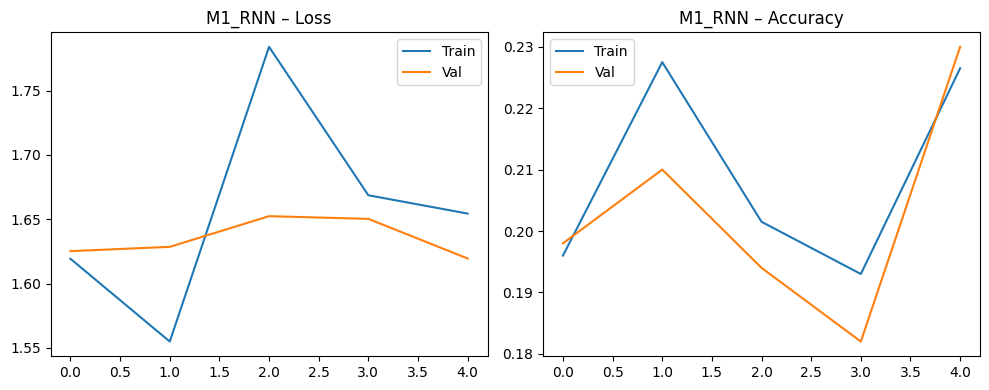


=== Model 2: Bi-LSTM (2-layer, Adam) ===
M2_BiLSTM | Epoch 01 | Train L:1.5307 A:0.3110 | Val   L:1.3439 A:0.4400
M2_BiLSTM | Epoch 02 | Train L:1.0523 A:0.5945 | Val   L:1.1145 A:0.5500
M2_BiLSTM | Epoch 03 | Train L:0.7671 A:0.7445 | Val   L:1.0057 A:0.6340
M2_BiLSTM | Epoch 04 | Train L:0.3745 A:0.8805 | Val   L:1.0217 A:0.6480
M2_BiLSTM | Epoch 05 | Train L:0.2297 A:0.9290 | Val   L:1.2137 A:0.6560


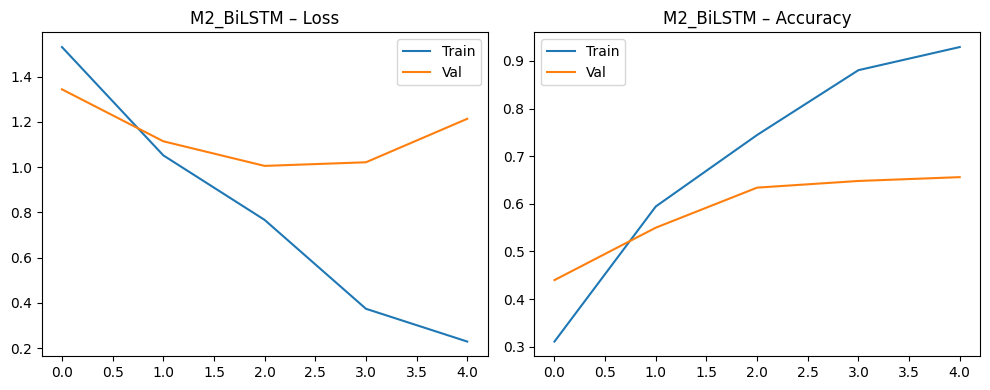


=== Model 3: GRU high-dropout (1-layer, SGD) ===
M3_GRU | Epoch 01 | Train L:1.6100 A:0.2020 | Val   L:1.6122 A:0.1880
M3_GRU | Epoch 02 | Train L:1.6115 A:0.1920 | Val   L:1.6121 A:0.2020
M3_GRU | Epoch 03 | Train L:1.6112 A:0.2050 | Val   L:1.6121 A:0.2040
M3_GRU | Epoch 04 | Train L:1.6092 A:0.2000 | Val   L:1.6120 A:0.2000
M3_GRU | Epoch 05 | Train L:1.6091 A:0.2005 | Val   L:1.6120 A:0.2000


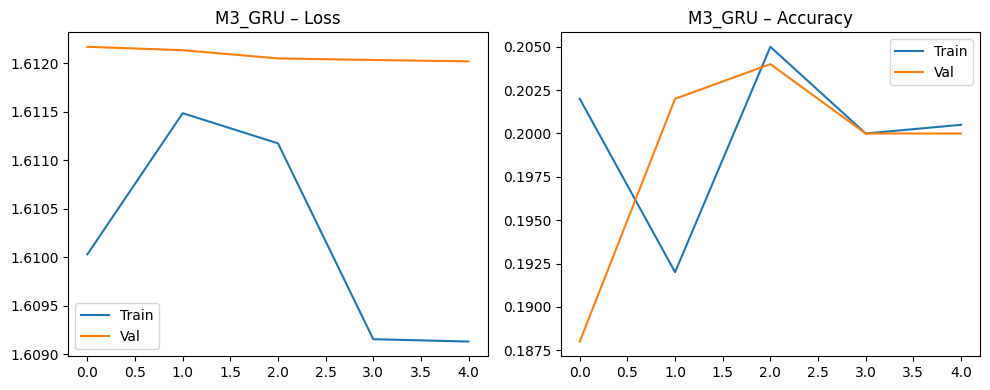


Final Test Accuracies → M1:0.2300 | M2:0.6560 | M3:0.2000


In [15]:
# 12. Run Three Models
print("\n=== Model 1: Basic RNN (1-layer, Adam) ===")
acc1 = train_one_model("M1_RNN", rnn_type='rnn', num_layers=1,
                       bidirectional=False, dropout=0.3,
                       optimizer_type='adam', epochs=5)

print("\n=== Model 2: Bi-LSTM (2-layer, Adam) ===")
acc2 = train_one_model("M2_BiLSTM", rnn_type='lstm', num_layers=2,
                       bidirectional=True, dropout=0.3,
                       optimizer_type='adam', epochs=5)

print("\n=== Model 3: GRU high-dropout (1-layer, SGD) ===")
acc3 = train_one_model("M3_GRU", rnn_type='gru', num_layers=1,
                       bidirectional=False, dropout=0.5,
                       optimizer_type='sgd', epochs=5)

print(f"\nFinal Test Accuracies → M1:{acc1:.4f} | M2:{acc2:.4f} | M3:{acc3:.4f}")


=== EXP1_Layers ===
EXP1_Layers_L1 | Epoch 01 | Train L:1.5558 A:0.3015 | Val   L:1.4533 A:0.4060
EXP1_Layers_L1 | Epoch 02 | Train L:1.1793 A:0.5640 | Val   L:1.1835 A:0.5300
EXP1_Layers_L1 | Epoch 03 | Train L:0.7847 A:0.7260 | Val   L:1.0581 A:0.5960
EXP1_Layers_L1 | Epoch 04 | Train L:0.4853 A:0.8460 | Val   L:0.9108 A:0.6920
EXP1_Layers_L1 | Epoch 05 | Train L:0.3774 A:0.8885 | Val   L:0.9390 A:0.6680
EXP1_Layers_L1 | Epoch 06 | Train L:0.2695 A:0.9265 | Val   L:0.8480 A:0.7200


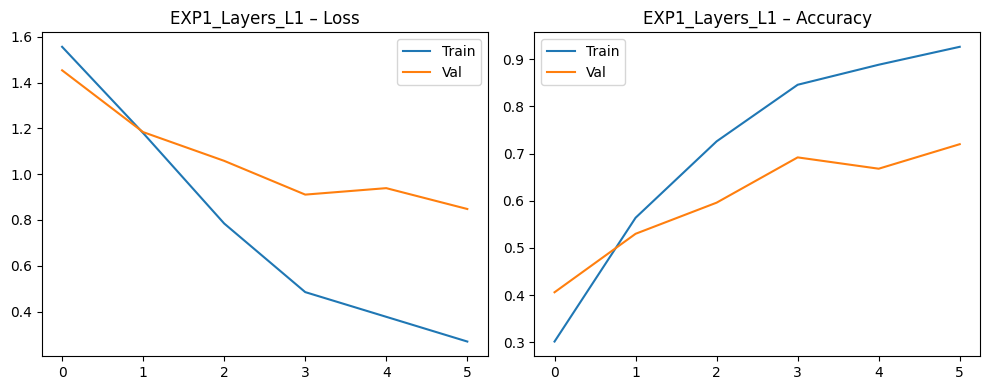

EXP1_Layers_L2 | Epoch 01 | Train L:1.5056 A:0.3260 | Val   L:1.3484 A:0.4560
EXP1_Layers_L2 | Epoch 02 | Train L:1.0949 A:0.5790 | Val   L:1.0926 A:0.5760
EXP1_Layers_L2 | Epoch 03 | Train L:0.7153 A:0.7430 | Val   L:1.0538 A:0.6120
EXP1_Layers_L2 | Epoch 04 | Train L:0.3900 A:0.8650 | Val   L:0.9827 A:0.6700
EXP1_Layers_L2 | Epoch 05 | Train L:0.2122 A:0.9330 | Val   L:0.9745 A:0.7160
EXP1_Layers_L2 | Epoch 06 | Train L:0.1993 A:0.9360 | Val   L:1.0693 A:0.6500


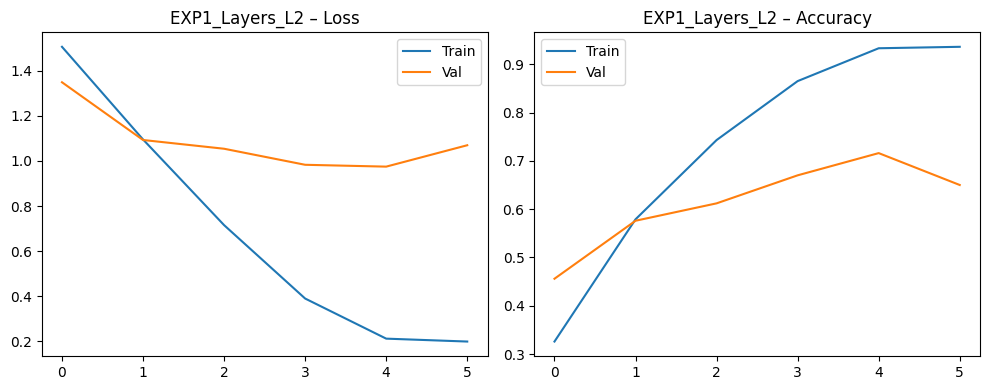

EXP1_Layers_L3 | Epoch 01 | Train L:1.4921 A:0.3480 | Val   L:1.2855 A:0.4800
EXP1_Layers_L3 | Epoch 02 | Train L:1.0465 A:0.6100 | Val   L:1.4228 A:0.5620
EXP1_Layers_L3 | Epoch 03 | Train L:0.6737 A:0.7720 | Val   L:1.1597 A:0.5740
EXP1_Layers_L3 | Epoch 04 | Train L:0.3898 A:0.8780 | Val   L:1.0150 A:0.6840
EXP1_Layers_L3 | Epoch 05 | Train L:0.2141 A:0.9445 | Val   L:1.1301 A:0.6660
EXP1_Layers_L3 | Epoch 06 | Train L:0.1563 A:0.9515 | Val   L:1.1637 A:0.6580


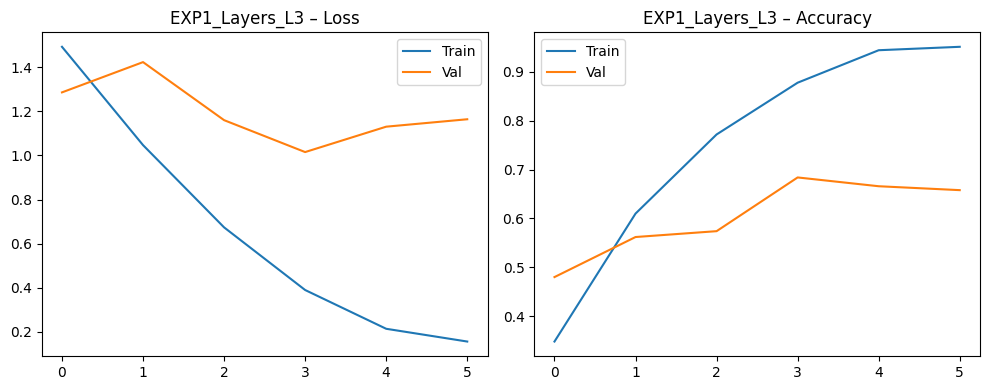

|   Layers |   Test Acc |
|---------:|-----------:|
|        1 |      0.72  |
|        2 |      0.65  |
|        3 |      0.658 |


In [16]:
# 1. How Many Layers? (Bi-LSTM, Adam, Dropout=0.3)
exp_name = "EXP1_Layers"
print(f"\n=== {exp_name} ===")
results = []

for nl in [1, 2, 3]:
    acc = train_one_model(f"{exp_name}_L{nl}", rnn_type='lstm', num_layers=nl,
                          bidirectional=True, dropout=0.3,
                          optimizer_type='adam', epochs=6)
    results.append([nl, f"{acc:.4f}"])

df1 = pd.DataFrame(results, columns=["Layers", "Test Acc"])
print(df1.to_markdown(index=False))


=== EXP2_Dropout ===
EXP2_Dropout_D0.2 | Epoch 01 | Train L:1.4961 A:0.3450 | Val   L:1.3311 A:0.4560
EXP2_Dropout_D0.2 | Epoch 02 | Train L:1.0511 A:0.6075 | Val   L:1.0563 A:0.6020
EXP2_Dropout_D0.2 | Epoch 03 | Train L:0.6510 A:0.7660 | Val   L:1.1022 A:0.6180
EXP2_Dropout_D0.2 | Epoch 04 | Train L:0.4574 A:0.8470 | Val   L:0.9583 A:0.6520
EXP2_Dropout_D0.2 | Epoch 05 | Train L:0.2861 A:0.9060 | Val   L:0.9968 A:0.6880
EXP2_Dropout_D0.2 | Epoch 06 | Train L:0.1695 A:0.9485 | Val   L:1.0586 A:0.7020


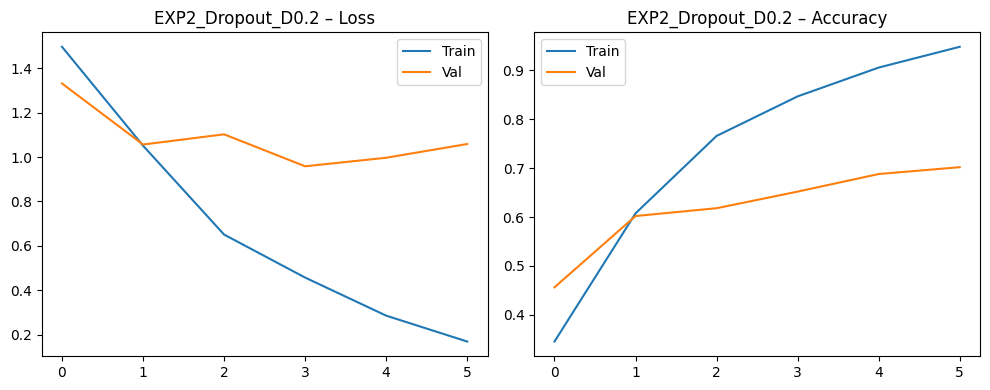

EXP2_Dropout_D0.3 | Epoch 01 | Train L:1.5097 A:0.3225 | Val   L:1.3253 A:0.4320
EXP2_Dropout_D0.3 | Epoch 02 | Train L:1.0270 A:0.5995 | Val   L:1.1114 A:0.5740
EXP2_Dropout_D0.3 | Epoch 03 | Train L:0.6809 A:0.7590 | Val   L:0.9552 A:0.6420
EXP2_Dropout_D0.3 | Epoch 04 | Train L:0.4092 A:0.8625 | Val   L:0.9159 A:0.6920
EXP2_Dropout_D0.3 | Epoch 05 | Train L:0.2281 A:0.9285 | Val   L:1.0488 A:0.6920
EXP2_Dropout_D0.3 | Epoch 06 | Train L:0.1410 A:0.9605 | Val   L:1.1377 A:0.6820


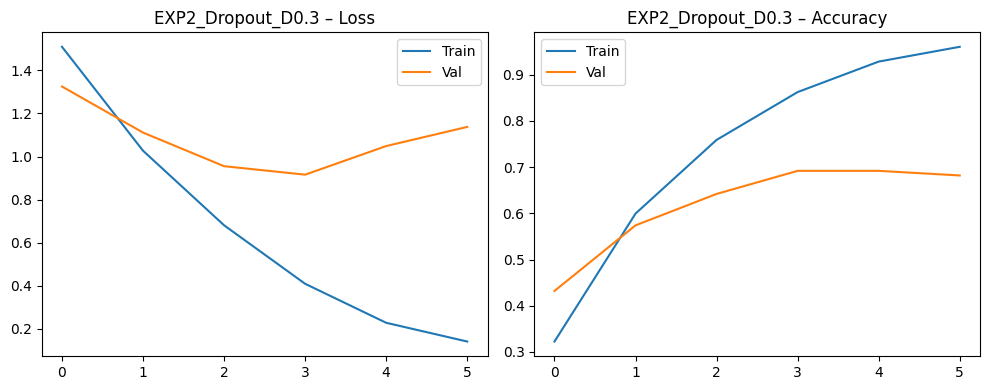

EXP2_Dropout_D0.5 | Epoch 01 | Train L:1.5489 A:0.3055 | Val   L:1.4149 A:0.3940
EXP2_Dropout_D0.5 | Epoch 02 | Train L:1.1598 A:0.5390 | Val   L:1.1509 A:0.5840
EXP2_Dropout_D0.5 | Epoch 03 | Train L:0.7912 A:0.7225 | Val   L:1.0015 A:0.6580
EXP2_Dropout_D0.5 | Epoch 04 | Train L:0.4606 A:0.8445 | Val   L:0.9963 A:0.6640
EXP2_Dropout_D0.5 | Epoch 05 | Train L:0.3043 A:0.9035 | Val   L:1.0185 A:0.6620
EXP2_Dropout_D0.5 | Epoch 06 | Train L:0.1685 A:0.9485 | Val   L:1.0800 A:0.6760


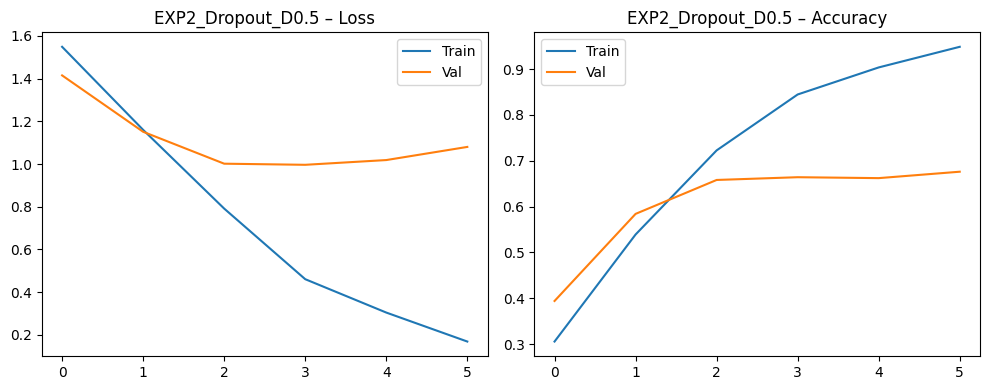

|   Dropout |   Test Acc |
|----------:|-----------:|
|       0.2 |      0.702 |
|       0.3 |      0.682 |
|       0.5 |      0.676 |


In [17]:
# 2. Dropout Regularisation (2-Layer Bi-LSTM)
exp_name = "EXP2_Dropout"
print(f"\n=== {exp_name} ===")
results = []

for do in [0.2, 0.3, 0.5]:
    acc = train_one_model(f"{exp_name}_D{do}", rnn_type='lstm', num_layers=2,
                          bidirectional=True, dropout=do,
                          optimizer_type='adam', epochs=6)
    results.append([do, f"{acc:.4f}"])

df2 = pd.DataFrame(results, columns=["Dropout", "Test Acc"])
print(df2.to_markdown(index=False))


=== EXP3_Optim ===
EXP3_Optim_ADAM | Epoch 01 | Train L:1.4890 A:0.3390 | Val   L:1.2770 A:0.4540
EXP3_Optim_ADAM | Epoch 02 | Train L:1.5212 A:0.4045 | Val   L:1.3292 A:0.4600
EXP3_Optim_ADAM | Epoch 03 | Train L:0.9961 A:0.6180 | Val   L:1.0818 A:0.5780
EXP3_Optim_ADAM | Epoch 04 | Train L:0.5635 A:0.8025 | Val   L:0.9659 A:0.6400
EXP3_Optim_ADAM | Epoch 05 | Train L:0.3693 A:0.8840 | Val   L:1.1057 A:0.6340
EXP3_Optim_ADAM | Epoch 06 | Train L:0.2499 A:0.9215 | Val   L:1.0840 A:0.6540


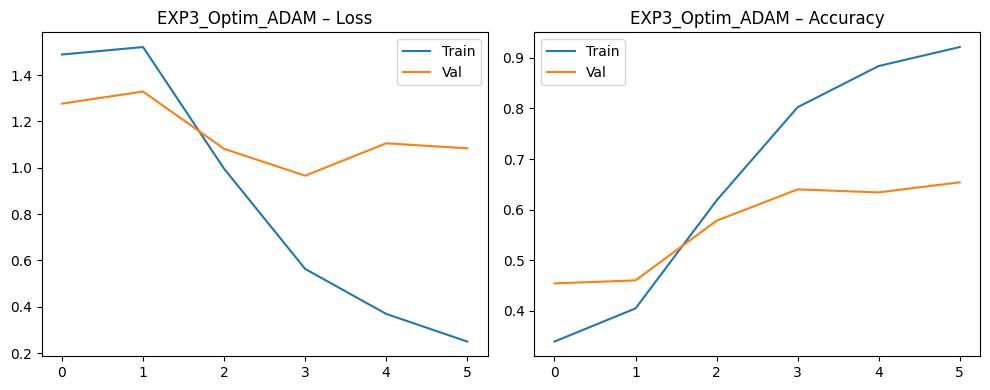

EXP3_Optim_SGD | Epoch 01 | Train L:1.6095 A:0.2080 | Val   L:1.6045 A:0.2680
EXP3_Optim_SGD | Epoch 02 | Train L:1.6026 A:0.2500 | Val   L:1.5984 A:0.3100
EXP3_Optim_SGD | Epoch 03 | Train L:1.5944 A:0.2905 | Val   L:1.5916 A:0.3040
EXP3_Optim_SGD | Epoch 04 | Train L:1.5881 A:0.3010 | Val   L:1.5879 A:0.3040
EXP3_Optim_SGD | Epoch 05 | Train L:1.5833 A:0.3130 | Val   L:1.5842 A:0.3060
EXP3_Optim_SGD | Epoch 06 | Train L:1.5785 A:0.3220 | Val   L:1.5802 A:0.3180


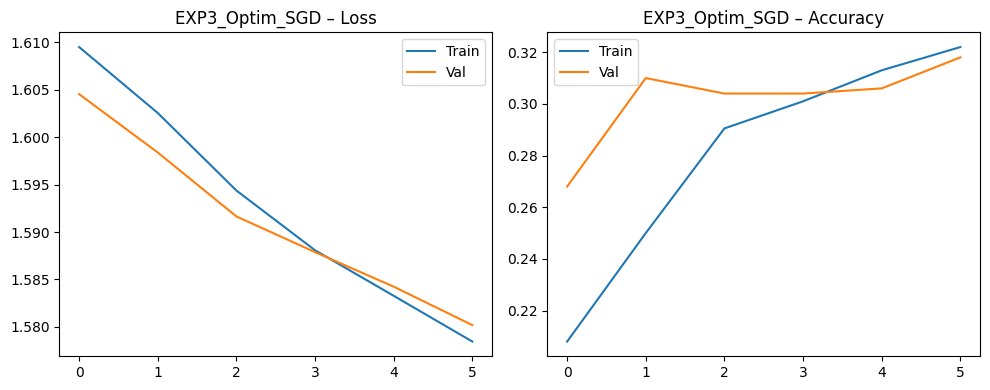

EXP3_Optim_RMSPROP | Epoch 01 | Train L:1.6106 A:0.1915 | Val   L:1.6095 A:0.2000
EXP3_Optim_RMSPROP | Epoch 02 | Train L:1.6101 A:0.1925 | Val   L:1.6088 A:0.2060
EXP3_Optim_RMSPROP | Epoch 03 | Train L:1.6091 A:0.2120 | Val   L:1.6083 A:0.2160
EXP3_Optim_RMSPROP | Epoch 04 | Train L:1.6079 A:0.2140 | Val   L:1.6080 A:0.2240
EXP3_Optim_RMSPROP | Epoch 05 | Train L:1.6085 A:0.2130 | Val   L:1.6077 A:0.2320
EXP3_Optim_RMSPROP | Epoch 06 | Train L:1.6071 A:0.2315 | Val   L:1.6075 A:0.2400


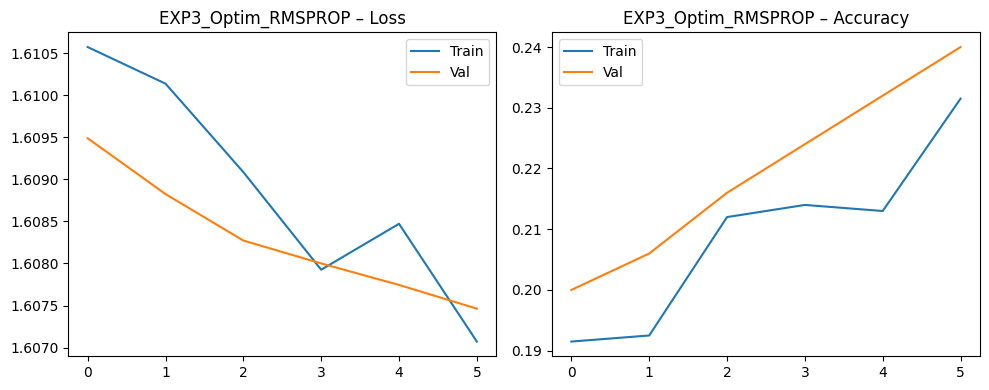

| Optimizer   |    LR |   Test Acc |
|:------------|------:|-----------:|
| ADAM        | 0.001 |      0.654 |
| SGD         | 0.01  |      0.318 |
| RMSPROP     | 0.001 |      0.24  |


In [18]:
# 3. Optimizer Comparison (2-Layer Bi-LSTM)
exp_name = "EXP3_Optim"
print(f"\n=== {exp_name} ===")
results = []

for opt, lr in [("adam",0.001), ("sgd",0.01), ("rmsprop",0.001)]:
    acc = train_one_model(f"{exp_name}_{opt.upper()}", rnn_type='lstm',
                          num_layers=2, bidirectional=True, dropout=0.3,
                          optimizer_type=opt, lr=lr, epochs=6)
    results.append([opt.upper(), lr, f"{acc:.4f}"])

df3 = pd.DataFrame(results, columns=["Optimizer", "LR", "Test Acc"])
print(df3.to_markdown(index=False))


=== EXP4_BiDir ===
EXP4_BiDir_BiFalse | Epoch 01 | Train L:1.6133 A:0.1945 | Val   L:1.6099 A:0.1960
EXP4_BiDir_BiFalse | Epoch 02 | Train L:1.5763 A:0.2345 | Val   L:1.6209 A:0.2200
EXP4_BiDir_BiFalse | Epoch 03 | Train L:1.5434 A:0.2475 | Val   L:1.6246 A:0.2180
EXP4_BiDir_BiFalse | Epoch 04 | Train L:1.5156 A:0.2515 | Val   L:1.6292 A:0.2200
EXP4_BiDir_BiFalse | Epoch 05 | Train L:1.5116 A:0.2380 | Val   L:1.6322 A:0.2100
EXP4_BiDir_BiFalse | Epoch 06 | Train L:1.5100 A:0.2390 | Val   L:1.6398 A:0.2140


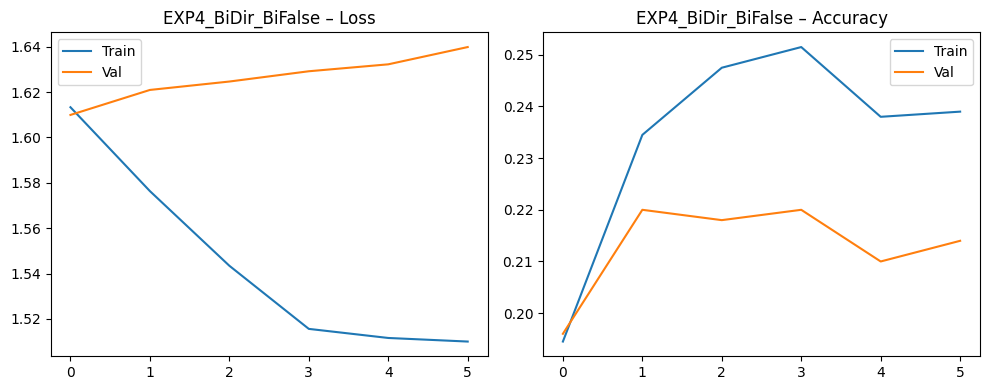

EXP4_BiDir_BiTrue | Epoch 01 | Train L:1.5455 A:0.3085 | Val   L:1.4316 A:0.4060
EXP4_BiDir_BiTrue | Epoch 02 | Train L:1.0944 A:0.5830 | Val   L:1.0646 A:0.5800
EXP4_BiDir_BiTrue | Epoch 03 | Train L:0.6622 A:0.7700 | Val   L:0.9597 A:0.6520
EXP4_BiDir_BiTrue | Epoch 04 | Train L:0.3241 A:0.9010 | Val   L:0.7738 A:0.7060
EXP4_BiDir_BiTrue | Epoch 05 | Train L:0.1971 A:0.9465 | Val   L:0.7250 A:0.7500
EXP4_BiDir_BiTrue | Epoch 06 | Train L:0.1146 A:0.9705 | Val   L:0.7420 A:0.7540


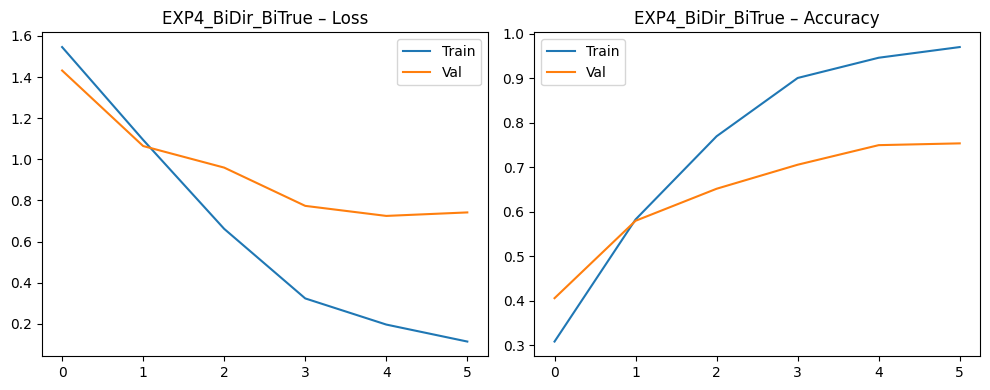

| Bidirectional   |   Test Acc |
|:----------------|-----------:|
| False           |      0.214 |
| True            |      0.754 |


In [19]:
# 4. Bidirectional Context (GRU, 1-Layer)
exp_name = "EXP4_BiDir"
print(f"\n=== {exp_name} ===")
results = []

for bi in [False, True]:
    acc = train_one_model(f"{exp_name}_Bi{bi}", rnn_type='gru', num_layers=1,
                          bidirectional=bi, dropout=0.3,
                          optimizer_type='adam', epochs=6)
    results.append([str(bi), f"{acc:.4f}"])

df4 = pd.DataFrame(results, columns=["Bidirectional", "Test Acc"])
print(df4.to_markdown(index=False))

In [20]:
# Final Summary (All Best Models)
summary = [
    ["Basic RNN (1L)",          acc1],
    ["Bi-LSTM (2L)",            acc2],
    ["GRU high-drop (1L)",      acc3],
    ["Bi-LSTM (3L) – EXP1",    float(df1.iloc[2,1])],
    ["Dropout 0.3 – EXP2",     float(df2.iloc[1,1])],
    ["Adam – EXP3",            float(df3.iloc[0,2])],
    ["Bi-GRU – EXP4",          float(df4.iloc[1,1])],
]
df_sum = pd.DataFrame(summary, columns=["Model", "Test Acc"])
print(df_sum.to_markdown(index=False))

| Model               |   Test Acc |
|:--------------------|-----------:|
| Basic RNN (1L)      |      0.23  |
| Bi-LSTM (2L)        |      0.656 |
| GRU high-drop (1L)  |      0.2   |
| Bi-LSTM (3L) – EXP1 |      0.658 |
| Dropout 0.3 – EXP2  |      0.682 |
| Adam – EXP3         |      0.654 |
| Bi-GRU – EXP4       |      0.754 |


Random seed fixed to 42

=== M1_RNN ===
M1_RNN | Epoch 01 | Train L:1.6167 A:0.1885 | Val   L:1.6158 A:0.2040
M1_RNN | Epoch 02 | Train L:1.5615 A:0.2360 | Val   L:1.6215 A:0.2180
M1_RNN | Epoch 03 | Train L:1.6719 A:0.2355 | Val   L:1.6595 A:0.1820
M1_RNN | Epoch 04 | Train L:1.6842 A:0.1850 | Val   L:1.6098 A:0.2060
M1_RNN | Epoch 05 | Train L:1.6455 A:0.2235 | Val   L:1.6157 A:0.2260
M1_RNN | Epoch 06 | Train L:1.6676 A:0.1945 | Val   L:1.6165 A:0.1960


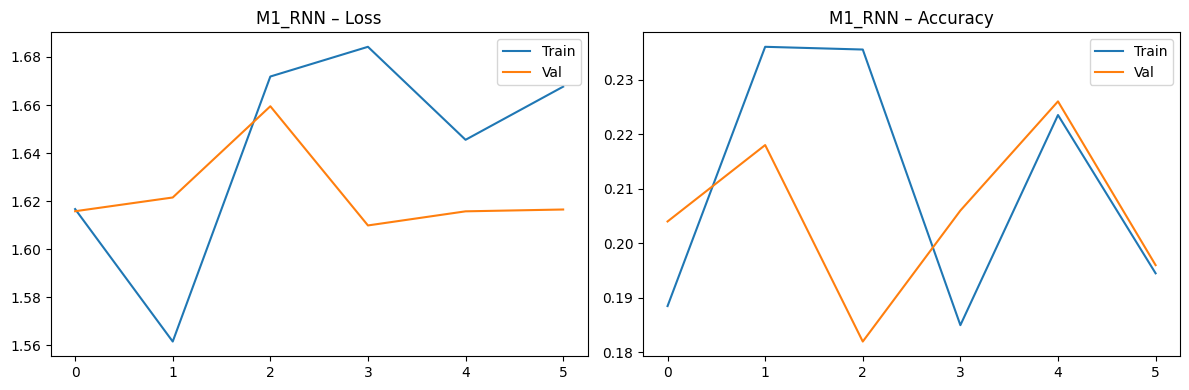

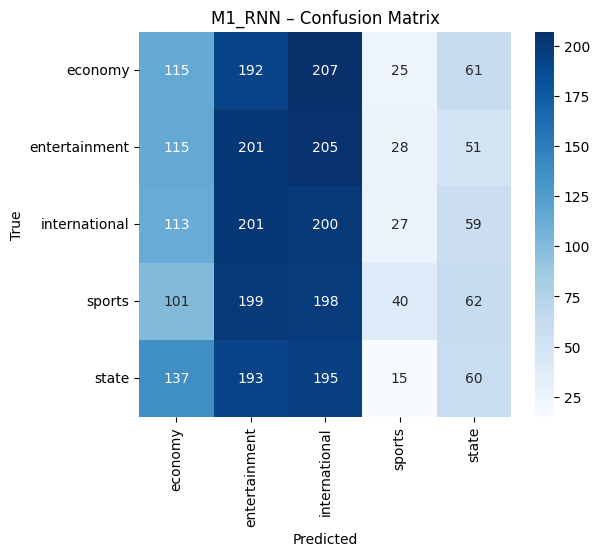

               precision  recall  f1-score    support
economy           0.1979  0.1917    0.1948   600.0000
entertainment     0.2039  0.3350    0.2535   600.0000
international     0.1990  0.3333    0.2492   600.0000
sports            0.2963  0.0667    0.1088   600.0000
state             0.2048  0.1000    0.1344   600.0000
accuracy          0.2053  0.2053    0.2053     0.2053
macro avg         0.2204  0.2053    0.1881  3000.0000
weighted avg      0.2204  0.2053    0.1881  3000.0000

=== M2_BiLSTM ===
M2_BiLSTM | Epoch 01 | Train L:1.5333 A:0.3165 | Val   L:1.3227 A:0.4280
M2_BiLSTM | Epoch 02 | Train L:1.1277 A:0.5745 | Val   L:1.1705 A:0.5260
M2_BiLSTM | Epoch 03 | Train L:0.7498 A:0.7290 | Val   L:1.0654 A:0.5980
M2_BiLSTM | Epoch 04 | Train L:0.4050 A:0.8660 | Val   L:1.0459 A:0.6360
M2_BiLSTM | Epoch 05 | Train L:0.2246 A:0.9365 | Val   L:1.1843 A:0.6300
M2_BiLSTM | Epoch 06 | Train L:0.1488 A:0.9590 | Val   L:1.1749 A:0.6420


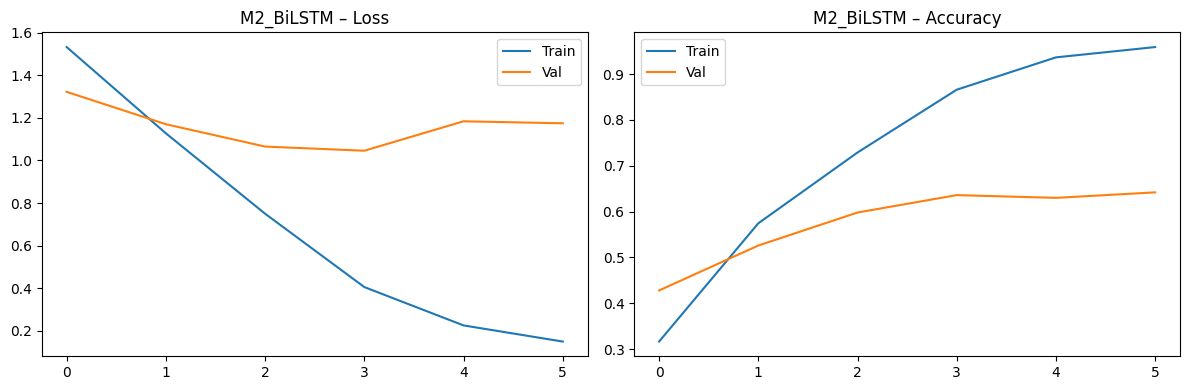

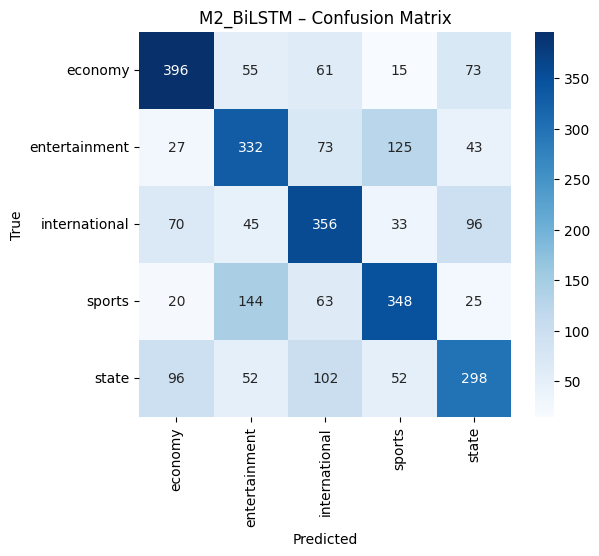

               precision  recall  f1-score    support
economy           0.6502  0.6600    0.6551   600.0000
entertainment     0.5287  0.5533    0.5407   600.0000
international     0.5435  0.5933    0.5673   600.0000
sports            0.6073  0.5800    0.5934   600.0000
state             0.5570  0.4967    0.5251   600.0000
accuracy          0.5767  0.5767    0.5767     0.5767
macro avg         0.5774  0.5767    0.5763  3000.0000
weighted avg      0.5774  0.5767    0.5763  3000.0000

=== M3_GRU ===
M3_GRU | Epoch 01 | Train L:1.6133 A:0.1800 | Val   L:1.6110 A:0.2020
M3_GRU | Epoch 02 | Train L:1.6069 A:0.1990 | Val   L:1.6101 A:0.2100
M3_GRU | Epoch 03 | Train L:1.6035 A:0.2115 | Val   L:1.6095 A:0.2060
M3_GRU | Epoch 04 | Train L:1.6001 A:0.2120 | Val   L:1.6094 A:0.2160
M3_GRU | Epoch 05 | Train L:1.5974 A:0.2190 | Val   L:1.6091 A:0.2120
M3_GRU | Epoch 06 | Train L:1.5968 A:0.2260 | Val   L:1.6089 A:0.2120


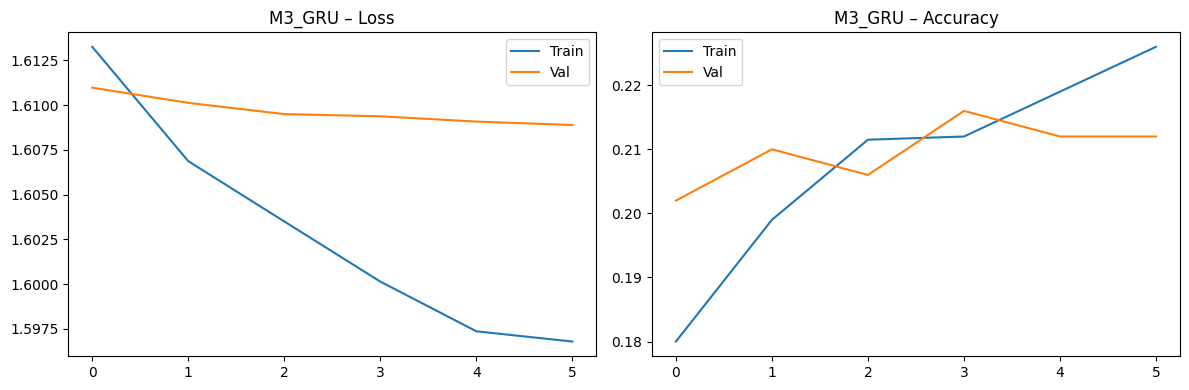

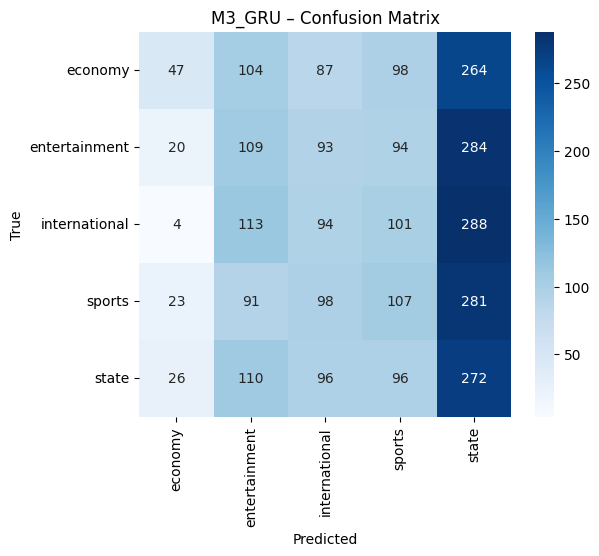

               precision  recall  f1-score    support
economy           0.3917  0.0783    0.1306   600.0000
entertainment     0.2068  0.1817    0.1934   600.0000
international     0.2009  0.1567    0.1760   600.0000
sports            0.2157  0.1783    0.1953   600.0000
state             0.1958  0.4533    0.2735   600.0000
accuracy          0.2097  0.2097    0.2097     0.2097
macro avg         0.2422  0.2097    0.1938  3000.0000
weighted avg      0.2422  0.2097    0.1938  3000.0000

=== Methodology (hyper-parameters) ===
| Model     | RNN   |   Layers | Bi-dir   |   Dropout | Optimizer   |    LR |   Epochs |
|:----------|:------|---------:|:---------|----------:|:------------|------:|---------:|
| M1_RNN    | RNN   |        1 | False    |       0.3 | ADAM        | 0.001 |        6 |
| M2_BiLSTM | LSTM  |        2 | True     |       0.3 | ADAM        | 0.001 |        6 |
| M3_GRU    | GRU   |        1 | False    |       0.5 | SGD         | 0.01  |        6 |

=== Final Results ===
| Mode

In [21]:
# Report-Ready Block (Methodology + Training + Results)
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import random, os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Random seed fixed to {SEED}")

def train_and_log(name, rnn_type, num_layers=1, bidirectional=False,
                  dropout=0.3, optimizer_type='adam', lr=0.001, epochs=6):
    model = RNNClassifier(len(vocab), rnn_type=rnn_type,
                          num_layers=num_layers, bidirectional=bidirectional,
                          dropout=dropout).to(device)

    opt = optim.Adam(model.parameters(), lr=lr) if optimizer_type=='adam' else \
          optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    scheduler = StepLR(opt, step_size=3, gamma=0.5)

    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []
    all_preds, all_labels = [], []

    for epoch in range(1, epochs+1):
        model.train()
        loss_sum = correct = total = 0
        for seq, lbl in train_loader:
            seq, lbl = seq.to(device), lbl.to(device)
            opt.zero_grad()
            out = model(seq)
            loss = crit(out, lbl)
            loss.backward()
            opt.step()
            loss_sum += loss.item()
            pred = out.argmax(1)
            correct += (pred == lbl).sum().item()
            total   += lbl.size(0)
        train_losses.append(loss_sum/len(train_loader))
        train_accs.append(correct/total)

        model.eval()
        vloss = vcorrect = vtotal = 0
        epoch_preds, epoch_labels = [], []
        with torch.no_grad():
            for seq, lbl in test_loader:
                seq, lbl = seq.to(device), lbl.to(device)
                out = model(seq)
                vloss += crit(out, lbl).item()
                pred = out.argmax(1)
                vcorrect += (pred == lbl).sum().item()
                vtotal   += lbl.size(0)
                epoch_preds.extend(pred.cpu().numpy())
                epoch_labels.extend(lbl.cpu().numpy())
        val_losses.append(vloss/len(test_loader))
        val_accs.append(vcorrect/vtotal)
        all_preds.extend(epoch_preds)
        all_labels.extend(epoch_labels)

        scheduler.step()
        print(f"{name} | Epoch {epoch:02d} | "
              f"Train L:{train_losses[-1]:.4f} A:{train_accs[-1]:.4f} | "
              f"Val   L:{val_losses[-1]:.4f} A:{val_accs[-1]:.4f}")

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
    plt.title(f'{name} – Loss'); plt.legend()
    plt.subplot(1,2,2); plt.plot(train_accs, label='Train'); plt.plot(val_accs, label='Val')
    plt.title(f'{name} – Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label2idx.keys(), yticklabels=label2idx.keys())
    plt.title(f'{name} – Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.show()

    report = classification_report(all_labels, all_preds,
                                   target_names=label2idx.keys(), output_dict=True)
    rep_df = pd.DataFrame(report).transpose().round(4)
    print(rep_df)

    return {
        'test_acc'   : val_accs[-1],
        'cm'         : cm,
        'report_df'  : rep_df,
        'history'    : {'train_loss':train_losses, 'val_loss':val_losses,
                        'train_acc':train_accs,   'val_acc':val_accs}
    }

experiments = [
    ("M1_RNN",      dict(rnn_type='rnn',  num_layers=1, bidirectional=False, dropout=0.3, optimizer_type='adam')),
    ("M2_BiLSTM",   dict(rnn_type='lstm',  num_layers=2, bidirectional=True,  dropout=0.3, optimizer_type='adam')),
    ("M3_GRU",      dict(rnn_type='gru',   num_layers=1, bidirectional=False, dropout=0.5, optimizer_type='sgd',  lr=0.01)),
]

results = {}
for name, cfg in experiments:
    print(f"\n=== {name} ===")
    results[name] = train_and_log(name, **cfg)

methodology = []
for name, cfg in experiments:
    cfg = {**{'epochs':6, 'lr':0.001}, **cfg}
    row = [name,
           cfg['rnn_type'].upper(),
           cfg['num_layers'],
           cfg['bidirectional'],
           cfg['dropout'],
           cfg['optimizer_type'].upper(),
           cfg['lr'],
           cfg['epochs']]
    methodology.append(row)

meth_df = pd.DataFrame(methodology,
        columns=["Model","RNN","Layers","Bi-dir","Dropout","Optimizer","LR","Epochs"])
print("\n=== Methodology (hyper-parameters) ===")
print(meth_df.to_markdown(index=False))

final = []
for name, log in results.items():
    final.append([name,
                  f"{log['test_acc']:.4f}",
                  f"{log['report_df'].loc['weighted avg','f1-score']:.4f}"])
final_df = pd.DataFrame(final, columns=["Model","Test Acc","Weighted F1"])
print("\n=== Final Results ===")
print(final_df.to_markdown(index=False))

print("\n=== Training Environment ===")
print(f"Device      : {device}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA avail. : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")

In [28]:
# QUICK VERIFICATION: Load the saved model & predict (FIXED PATH)
import torch
import torch.nn as nn
import re
import os

MODEL_PATH = "/content/drive/MyDrive/NNFLL/bangla_news_classifier/best_bigru_model_final.pth"

if not os.path.exists(MODEL_PATH):
    print("File not found! Check these common paths:")
    print("   /content/drive/MyDrive/NNFLL/best_bigru_model_final.pth")
    print("   /content/drive/MyDrive/NNFLL/bangla_news_classifier/best_bigru_model_final.pth")
    raise FileNotFoundError(MODEL_PATH)
else:
    print(f"Found model at: {MODEL_PATH}\n")


class BestBiGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, num_classes=5, dropout=0.5, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0,
                          bidirectional=bidirectional)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.gru(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.fc(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BestBiGRU(vocab_size=len(vocab), embed_dim=128, hidden_dim=256,
                  num_layers=2, num_classes=5, dropout=0.5, bidirectional=True)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!\n")

idx2label = {0: 'economy', 1: 'entertainment', 2: 'international', 3: 'sports', 4: 'state'}

def predict_text(text):
    text = re.sub(r'^["\']|["\']$', '', text.strip())
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\u0980-\u09FF\s.,!?]', '', text).strip()

    tokens = text.split()
    indices = [word2idx.get(w, word2idx.get('<UNK>', 1)) for w in tokens]

    if len(indices) > 500:
        indices = indices[:500]
    else:
        indices += [0] * (500 - len(indices))

    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        prob = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(prob, dim=1).item()
        confidence = prob[0][pred_idx].item()

    return idx2label[pred_idx], confidence


samples = [
    "বাংলাদেশ ক্রিকেট দল আজ ভারতের বিপক্ষে ম্যাচ খেলবে",
    "চলচ্চিত্র অভিনেত্রী শাবনূর নতুন সিনেমায় অভিনয় করছেন",
    "অর্থনীতি মন্ত্রণালয় নতুন বাজেট ঘোষণা করেছে",
    "যুক্তরাষ্ট্রে বন্দুক হামলায় ১০ জন নিহত",
    "ঢাকায় বন্যার কারণে সড়ক যোগাযোগ বন্ধ",
]

print("="*60)
print("PREDICTIONS")
print("="*60)
for text in samples:
    label, conf = predict_text(text)
    short = text[:60] + ("..." if len(text)>60 else "")
    print(f"Text : {short}")
    print(f"   → Predicted : {label.upper():12} | Confidence : {conf:.3f}\n")

Found model at: /content/drive/MyDrive/NNFLL/bangla_news_classifier/best_bigru_model_final.pth

Model loaded successfully!

PREDICTIONS
Text : বাংলাদেশ ক্রিকেট দল আজ ভারতের বিপক্ষে ম্যাচ খেলবে
   → Predicted : INTERNATIONAL | Confidence : 0.208

Text : চলচ্চিত্র অভিনেত্রী শাবনূর নতুন সিনেমায় অভিনয় করছেন
   → Predicted : INTERNATIONAL | Confidence : 0.208

Text : অর্থনীতি মন্ত্রণালয় নতুন বাজেট ঘোষণা করেছে
   → Predicted : INTERNATIONAL | Confidence : 0.208

Text : যুক্তরাষ্ট্রে বন্দুক হামলায় ১০ জন নিহত
   → Predicted : INTERNATIONAL | Confidence : 0.208

Text : ঢাকায় বন্যার কারণে সড়ক যোগাযোগ বন্ধ
   → Predicted : INTERNATIONAL | Confidence : 0.208

